<a href="https://colab.research.google.com/github/dinusariehewage-coder/ET3112-/blob/main/Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

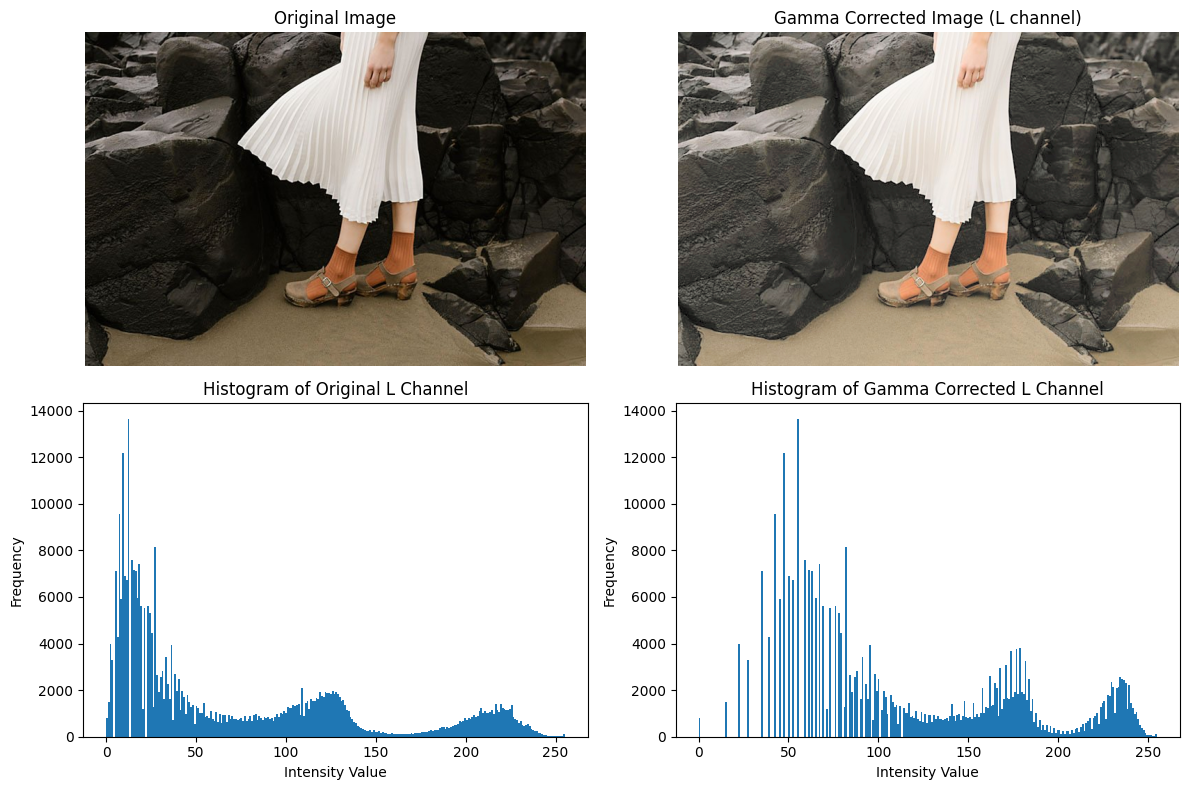

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


image_path = '/Assignment 01/highlights_and_shadows.jpg'


# Read image (OpenCV reads in BGR)
img_bgr = cv.imread(image_path)

# Safety check
if img_bgr is None:
    raise FileNotFoundError("Image not found. Check the image path and filename.")

# Convert BGR to RGB for correct display
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)


# Convert RGB to L*a*b* color space

img_lab = cv.cvtColor(img_rgb, cv.COLOR_RGB2LAB)

# Split L, a, b channels
L, a, b = cv.split(img_lab)

# Normalize L channel to [0,1]
L_norm = L / 255.0


# (a) Gamma correction on L channel

gamma = 0.5   # <-- γ value (you can state this in your answer)

L_gamma = L_norm ** gamma

# Scale back to [0,255]
L_gamma = np.uint8(L_gamma * 255)

# Merge corrected L with original a and b channels
img_lab_gamma = cv.merge([L_gamma, a, b])

# Convert back to RGB for display
img_rgb_gamma = cv.cvtColor(img_lab_gamma, cv.COLOR_LAB2RGB)


# (b) Histograms of original and corrected L channel

plt.figure(figsize=(12, 8))

# Original image
plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

# Gamma corrected image
plt.subplot(2, 2, 2)
plt.imshow(img_rgb_gamma)
plt.title('Gamma Corrected Image (L channel)')
plt.axis('off')

# Histogram of original L channel
plt.subplot(2, 2, 3)
plt.hist(L.flatten(), bins=256, range=(0, 255))
plt.title('Histogram of Original L Channel')
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')

# Histogram of gamma-corrected L channel
plt.subplot(2, 2, 4)
plt.hist(L_gamma.flatten(), bins=256, range=(0, 255))
plt.title('Histogram of Gamma Corrected L Channel')
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
